In [1]:
# ============================================================
# 0. Imports and global settings
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# ----------------------------
# Experiment settings
# ----------------------------
# Ten seeds are used for both protocols.
WHOLE_CV_SEEDS = list(range(10))
HOLDOUT_SEEDS = list(range(10))

CV_SPLITS = 5
TEST_SIZE = 0.20

# RF settings: keep fixed so evaluation variability is not mixed with model-randomness variability.
N_ESTIMATORS = 200
MIN_SAMPLES_LEAF = 1
RF_RANDOM_STATE = 42
N_JOBS_RF = -1

PCE_TARGET = "jv.default_PCE"
JV_TARGETS = ["jv.default_Jsc", "jv.default_Voc", "jv.default_FF"]
TARGETS_TO_RUN = JV_TARGETS + [PCE_TARGET]

OUTPUT_DIR = Path("allin_wholecv_vs_holdout_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Settings")
print("-" * 60)
print("WHOLE_CV_SEEDS:", WHOLE_CV_SEEDS)
print("HOLDOUT_SEEDS:", HOLDOUT_SEEDS)
print("CV_SPLITS:", CV_SPLITS)
print("TEST_SIZE:", TEST_SIZE)
print("N_ESTIMATORS:", N_ESTIMATORS)
print("MIN_SAMPLES_LEAF:", MIN_SAMPLES_LEAF)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


Settings
------------------------------------------------------------
WHOLE_CV_SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
HOLDOUT_SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
CV_SPLITS: 5
TEST_SIZE: 0.2
N_ESTIMATORS: 200
MIN_SAMPLES_LEAF: 1
OUTPUT_DIR: /Users/rosylu/Desktop/PVK/new/allin_wholecv_vs_holdout_outputs


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = Path("df_base.csv")

df_base = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Loaded fixed dataset: {DATA_PATH.resolve()}")
print("df_base shape:", df_base.shape)
print("First 10 columns:", df_base.columns[:10].tolist())

Loaded fixed dataset: /Users/rosylu/Desktop/PVK/new/df_base_strict.csv
df_base shape: (3182, 411)
First 10 columns: ['m_def', 'ref.internal_sample_id', 'ref.ID', 'ref.ID_temp', 'ref.name_of_person_entering_the_data', 'ref.data_entered_by_author', 'ref.DOI_number', 'ref.lead_author', 'ref.publication_date', 'ref.journal']


In [3]:
# ============================================================
# 2. Build canonical all-in X and target table Y
# ============================================================

# Frozen canonical all-in feature set:
# - all eligible non-leakage raw descriptors with <50% missingness;
# - five duplicated raw thickness/band-gap fields replaced by clean versions;
# - three layer-count helpers;
# - two Level-3 engineered thickness features.
ALL_IN_FEATURES = [
    "etl.additives_compounds",
    "encapsulation.edge_sealing_materials",
    "perovskite_bandgap_clean",
    "perovskite.band_gap_graded",
    "perovskite.composition_a_ions",
    "perovskite.composition_a_ions_coefficients",
    "perovskite.composition_b_ions",
    "perovskite.composition_b_ions_coefficients",
    "perovskite.composition_c_ions",
    "perovskite.composition_c_ions_coefficients",
    "perovskite.composition_inorganic",
    "perovskite.composition_leadfree",
    "perovskite.composition_long_form",
    "perovskite.composition_perovskite_ABC3_structure",
    "perovskite.composition_perovskite_inspired_structure",
    "perovskite.composition_short_form",
    "perovskite.dimension_0D",
    "perovskite.dimension_2D",
    "perovskite.dimension_2D3D_mixture",
    "perovskite.dimension_3D",
    "perovskite.dimension_3D_with_2D_capping_layer",
    "perovskite.dimension_list_of_layers",
    "perovskite.ions",
    "perovskite.single_crystal",
    "PVK_thickness_clean",
    "add.lay_back",
    "add.lay_front",
    "add.lay_back_stack_sequence",
    "add.lay_front_stack_sequence",
    "backcontact.stack_sequence",
    "BC_thickness_clean",
    "cell.architecture",
    "cell.area_measured",
    "cell.flexible",
    "cell.number_of_cells_per_substrate",
    "cell.semitransparent",
    "cell.semitransparent_wavelength_range",
    "cell.stack_sequence",
    "etl.stack_sequence",
    "ETL_thickness_clean",
    "encapsulation.Encapsulation",
    "encapsulation.stack_sequence",
    "htl.stack_sequence",
    "HTL_thickness_clean",
    "module.Module",
    "module.number_of_cells_in_module",
    "substrate.stack_sequence",
    "perovskite_deposition.aggregation_state_of_reactants",
    "perovskite_deposition.number_of_deposition_steps",
    "perovskite_deposition.procedure",
    "perovskite_deposition.substrate_temperature",
    "perovskite_deposition.synthesis_atmosphere",
    "add.lay_back_deposition_aggregation_state_of_reactants",
    "add.lay_back_deposition_procedure",
    "add.lay_back_deposition_reaction_solutions_age",
    "add.lay_back_deposition_reaction_solutions_compounds_purity",
    "add.lay_back_deposition_reaction_solutions_compounds_supplier",
    "add.lay_back_deposition_reaction_solutions_temperature",
    "add.lay_back_deposition_reaction_solutions_volumes",
    "add.lay_back_deposition_solvents",
    "add.lay_back_deposition_solvents_purity",
    "add.lay_back_deposition_solvents_supplier",
    "add.lay_back_deposition_substrate_temperature",
    "add.lay_back_deposition_synthesis_atmosphere",
    "add.lay_back_deposition_thermal_annealing_atmosphere",
    "add.lay_back_deposition_thermal_annealing_temperature",
    "add.lay_back_deposition_thermal_annealing_time",
    "add.lay_front_deposition_aggregation_state_of_reactants",
    "add.lay_front_deposition_procedure",
    "add.lay_front_deposition_reaction_solutions_age",
    "add.lay_front_deposition_reaction_solutions_compounds_purity",
    "add.lay_front_deposition_reaction_solutions_compounds_supplier",
    "add.lay_front_deposition_reaction_solutions_temperature",
    "add.lay_front_deposition_reaction_solutions_volumes",
    "add.lay_front_deposition_solvents",
    "add.lay_front_deposition_solvents_purity",
    "add.lay_front_deposition_solvents_supplier",
    "add.lay_front_deposition_substrate_temperature",
    "add.lay_front_deposition_synthesis_atmosphere",
    "add.lay_front_deposition_thermal_annealing_atmosphere",
    "add.lay_front_deposition_thermal_annealing_temperature",
    "add.lay_front_deposition_thermal_annealing_time",
    "backcontact.deposition_aggregation_state_of_reactants",
    "backcontact.deposition_procedure",
    "backcontact.deposition_substrate_temperature",
    "backcontact.deposition_synthesis_atmosphere",
    "backcontact.deposition_reaction_solutions_age",
    "backcontact.deposition_reaction_solutions_compounds_purity",
    "backcontact.deposition_reaction_solutions_compounds_supplier",
    "backcontact.deposition_reaction_solutions_temperature",
    "backcontact.deposition_reaction_solutions_volumes",
    "backcontact.deposition_solvents",
    "backcontact.deposition_solvents_purity",
    "backcontact.deposition_solvents_supplier",
    "backcontact.deposition_thermal_annealing_atmosphere",
    "backcontact.deposition_thermal_annealing_temperature",
    "backcontact.deposition_thermal_annealing_time",
    "etl.deposition_aggregation_state_of_reactants",
    "etl.deposition_procedure",
    "etl.deposition_substrate_temperature",
    "etl.deposition_synthesis_atmosphere",
    "etl.deposition_reaction_solutions_age",
    "etl.deposition_reaction_solutions_compounds_purity",
    "etl.deposition_reaction_solutions_compounds_supplier",
    "etl.deposition_reaction_solutions_temperature",
    "etl.deposition_reaction_solutions_volumes",
    "etl.deposition_solvents",
    "etl.deposition_solvents_purity",
    "etl.deposition_solvents_supplier",
    "etl.deposition_thermal_annealing_atmosphere",
    "etl.deposition_thermal_annealing_temperature",
    "etl.deposition_thermal_annealing_time",
    "encapsulation.atmosphere_for_encapsulation",
    "htl.deposition_aggregation_state_of_reactants",
    "htl.deposition_procedure",
    "htl.deposition_substrate_temperature",
    "htl.deposition_synthesis_atmosphere",
    "htl.deposition_reaction_solutions_age",
    "htl.deposition_reaction_solutions_compounds_purity",
    "htl.deposition_reaction_solutions_compounds_supplier",
    "htl.deposition_reaction_solutions_temperature",
    "htl.deposition_reaction_solutions_volumes",
    "htl.deposition_solvents",
    "htl.deposition_solvents_purity",
    "htl.deposition_solvents_supplier",
    "htl.deposition_thermal_annealing_atmosphere",
    "htl.deposition_thermal_annealing_temperature",
    "htl.deposition_thermal_annealing_time",
    "add.lay_back_storage_atmosphere",
    "add.lay_back_storage_time_until_next_deposition_step",
    "add.lay_front_storage_atmosphere",
    "add.lay_front_storage_time_until_next_deposition_step",
    "backcontact.storage_atmosphere",
    "backcontact.storage_time_until_next_deposition_step",
    "etl.storage_atmosphere",
    "htl.storage_atmosphere",
    "htl.storage_time_until_next_deposition_step",
    "perovskite.storage_atmosphere",
    "perovskite.storage_time_until_next_deposition_step",
    "perovskite_deposition.reaction_solutions_age",
    "perovskite_deposition.reaction_solutions_compounds_purity",
    "perovskite_deposition.reaction_solutions_compounds_supplier",
    "perovskite_deposition.reaction_solutions_temperature",
    "perovskite_deposition.reaction_solutions_volumes",
    "perovskite_deposition.solvents",
    "perovskite_deposition.solvents_mixing_ratios",
    "perovskite_deposition.solvents_purity",
    "perovskite_deposition.solvents_supplier",
    "perovskite_deposition.quenching_induced_crystallisation",
    "perovskite_deposition.quenching_media",
    "perovskite_deposition.quenching_media_volume",
    "perovskite_deposition.solvent_annealing",
    "perovskite_deposition.solvent_annealing_solvent_atmosphere",
    "perovskite_deposition.solvent_annealing_temperature",
    "perovskite_deposition.solvent_annealing_time",
    "substrate.deposition_procedure",
    "perovskite_deposition.thermal_annealing_atmosphere",
    "perovskite_deposition.thermal_annealing_temperature",
    "perovskite_deposition.thermal_annealing_time",
    "perovskite.band_gap_estimation_basis",
    "jv.certified_values",
    "eqe.measured",
    "jv.average_over_n_number_of_cells",
    "jv.light_intensity",
    "jv.light_masked_cell",
    "jv.light_spectra",
    "jv.light_wavelength_range",
    "jv.measured",
    "jv.storage_age_of_cell",
    "jv.storage_atmosphere",
    "jv.test_atmosphere",
    "module.JV_data_recalculated_per_cell",
    "outdoor.average_over_n_number_of_cells",
    "outdoor.detaild_weather_data_available",
    "outdoor.installation_number_of_solar_tracking_axis",
    "outdoor.irradiance_measured",
    "outdoor.location_coordinates",
    "outdoor.periodic_JV_measurements",
    "outdoor.potential_bias_range",
    "outdoor.spectral_data_available",
    "outdoor.temperature_range",
    "outdoor.tested",
    "outdoor.time_end",
    "outdoor.time_start",
    "jv.default_FF_scan_direction",
    "jv.default_Jsc_scan_direction",
    "jv.default_PCE_scan_direction",
    "jv.default_Voc_scan_direction",
    "stabilised.performance_measured",
    "stability.atmosphere",
    "stability.average_over_n_number_of_cells",
    "stability.flexible_cell_number_of_bending_cycles",
    "stability.light_UV_filter",
    "stability.light_cycling_times",
    "stability.light_wavelength_range",
    "stability.measured",
    "stability.periodic_JV_measurements",
    "stability.periodic_JV_measurements_time_between_jv",
    "stability.potential_bias_range",
    "stability.relative_humidity_range",
    "stability.temperature_cycling_times",
    "stability.temperature_range",
    "ETL_n_layers",
    "HTL_n_layers",
    "BC_n_layers",
    "Absorber_to_ETL_ratio",
    "ff_PVK_fraction_of_total_stack"
]

RAW_DUPLICATE_FEATURES = [
    "perovskite.band_gap",
    "perovskite.thickness",
    "etl.thickness",
    "htl.thickness_list",
    "backcontact.thickness_list",
]

LEVEL3_FEATURES = [
    "Absorber_to_ETL_ratio",
    "ff_PVK_fraction_of_total_stack",
]


def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return (numerator / denominator).replace([np.inf, -np.inf], np.nan)


# Create only the two agreed Level-3 features.
pvk = pd.to_numeric(df_base["PVK_thickness_clean"], errors="coerce")
etl = pd.to_numeric(df_base["ETL_thickness_clean"], errors="coerce")
htl = pd.to_numeric(df_base["HTL_thickness_clean"], errors="coerce")
bc = pd.to_numeric(df_base["BC_thickness_clean"], errors="coerce")

df_base["Absorber_to_ETL_ratio"] = safe_divide(pvk, etl)
df_base["ff_PVK_fraction_of_total_stack"] = safe_divide(
    pvk,
    pvk + etl + htl + bc,
)

NEEDED_TARGETS = JV_TARGETS + [PCE_TARGET]

missing_targets = [c for c in NEEDED_TARGETS if c not in df_base.columns]
if missing_targets:
    raise ValueError("Missing target columns in df_base: " + ", ".join(missing_targets))

missing_features = [c for c in ALL_IN_FEATURES if c not in df_base.columns]
if missing_features:
    raise ValueError(
        "Missing canonical all-in features in df_base: "
        + ", ".join(missing_features)
    )

assert len(ALL_IN_FEATURES) == 207
assert len(ALL_IN_FEATURES) == len(set(ALL_IN_FEATURES))
assert set(RAW_DUPLICATE_FEATURES).isdisjoint(ALL_IN_FEATURES)
assert set(LEVEL3_FEATURES).issubset(ALL_IN_FEATURES)

Y_all = df_base[NEEDED_TARGETS].copy()
for col in NEEDED_TARGETS:
    Y_all[col] = pd.to_numeric(Y_all[col], errors="coerce")

mask = Y_all.notna().all(axis=1)
Y = Y_all.loc[mask].copy()

X_all = df_base.loc[mask, ALL_IN_FEATURES].copy()
X_all = X_all.replace({pd.NA: np.nan})

print("Samples used:", len(X_all))
print("Canonical all-in features:", X_all.shape[1])
print("Targets:", Y.shape)
print("Numeric all-in features:", len(X_all.select_dtypes(include=np.number).columns))
print("Categorical all-in features:", X_all.shape[1] - len(X_all.select_dtypes(include=np.number).columns))
print("Level-3 features included:", LEVEL3_FEATURES)
print("First 20 all-in features:")
print(X_all.columns[:20].tolist())

pd.Series(X_all.columns, name="allin_feature").to_csv(
    OUTPUT_DIR / "allin_feature_list.csv",
    index=False,
)


Samples used: 3182
Canonical all-in features: 207
Targets: (3182, 4)
Numeric all-in features: 20
Categorical all-in features: 187
Level-3 features included: ['Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']
First 20 all-in features:
['etl.additives_compounds', 'encapsulation.edge_sealing_materials', 'perovskite_bandgap_clean', 'perovskite.band_gap_graded', 'perovskite.composition_a_ions', 'perovskite.composition_a_ions_coefficients', 'perovskite.composition_b_ions', 'perovskite.composition_b_ions_coefficients', 'perovskite.composition_c_ions', 'perovskite.composition_c_ions_coefficients', 'perovskite.composition_inorganic', 'perovskite.composition_leadfree', 'perovskite.composition_long_form', 'perovskite.composition_perovskite_ABC3_structure', 'perovskite.composition_perovskite_inspired_structure', 'perovskite.composition_short_form', 'perovskite.dimension_0D', 'perovskite.dimension_2D', 'perovskite.dimension_2D3D_mixture', 'perovskite.dimension_3D']


In [4]:
# ============================================================
# 3. Modelling helpers
# ============================================================


def make_rf_pipeline(X, rf_random_state=RF_RANDOM_STATE):
    """Create the same all-in preprocessing + RF pipeline for any raw feature matrix X."""
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("to_str", FunctionTransformer(lambda x: x.astype(str), validate=False)),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ])

    rf = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=rf_random_state,
        n_jobs=N_JOBS_RF,
    )

    return Pipeline([
        ("prep", preprocessor),
        ("rf", rf),
    ])


def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def safe_target_name(target):
    return target.replace("jv.default_", "")


def summarise_range(s):
    return s.max() - s.min()


In [5]:
# ============================================================
# 4. Whole-dataset repeated 5-fold CV
# ============================================================

whole_cv_rows = []
whole_cv_partial_path = OUTPUT_DIR / "whole_dataset_cv_results_PARTIAL.csv"
whole_cv_final_path = OUTPUT_DIR / "whole_dataset_cv_results.csv"

print("Starting Experiment A: whole-dataset repeated CV")
print(f"  n CV seeds: {len(WHOLE_CV_SEEDS)}")
print(f"  CV splits: {CV_SPLITS}")
print(f"  targets: {TARGETS_TO_RUN}")
print(f"  Partial output: {whole_cv_partial_path}")

for cv_seed in WHOLE_CV_SEEDS:
    print("\n" + "=" * 90)
    print(f"Whole-dataset CV seed {cv_seed}")
    print("=" * 90)

    cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=cv_seed)

    for target in TARGETS_TO_RUN:
        target_short = safe_target_name(target)
        y = Y[target]
        model = make_rf_pipeline(X_all, rf_random_state=RF_RANDOM_STATE)

        cv_out = cross_validate(
            model,
            X_all,
            y,
            cv=cv,
            scoring={
                "r2": "r2",
                "rmse": "neg_root_mean_squared_error",
            },
            n_jobs=1,
            return_train_score=False,
        )

        fold_r2 = cv_out["test_r2"]
        fold_rmse = -cv_out["test_rmse"]

        row = {
            "evaluation": "whole_dataset_cv",
            "cv_seed": cv_seed,
            "target": target,
            "target_short": target_short,
            "n_samples": len(X_all),
            "n_raw_features": X_all.shape[1],
            "cv_splits": CV_SPLITS,
            "n_estimators": N_ESTIMATORS,
            "min_samples_leaf": MIN_SAMPLES_LEAF,
            "CV_R2_mean": fold_r2.mean(),
            "CV_R2_std_within_run": fold_r2.std(ddof=1),
            "CV_R2_min_fold": fold_r2.min(),
            "CV_R2_max_fold": fold_r2.max(),
            "CV_RMSE_mean": fold_rmse.mean(),
            "CV_RMSE_std_within_run": fold_rmse.std(ddof=1),
            "CV_RMSE_min_fold": fold_rmse.min(),
            "CV_RMSE_max_fold": fold_rmse.max(),
        }
        whole_cv_rows.append(row)
        pd.DataFrame(whole_cv_rows).to_csv(whole_cv_partial_path, index=False)

        print(
            f"  {target_short:<4} | CV R2={row['CV_R2_mean']:.4f} ± {row['CV_R2_std_within_run']:.4f} "
            f"| CV RMSE={row['CV_RMSE_mean']:.4f} ± {row['CV_RMSE_std_within_run']:.4f}"
        )

whole_cv_df = pd.DataFrame(whole_cv_rows)
whole_cv_df.to_csv(whole_cv_final_path, index=False)

print("\nExperiment A done.")
print("Saved:", whole_cv_final_path)
display(whole_cv_df.head())


Starting Experiment A: whole-dataset repeated CV
  n CV seeds: 10
  CV splits: 5
  targets: ['jv.default_Jsc', 'jv.default_Voc', 'jv.default_FF', 'jv.default_PCE']
  Partial output: allin_wholecv_vs_holdout_outputs/whole_dataset_cv_results_PARTIAL.csv

Whole-dataset CV seed 0
  Jsc  | CV R2=0.6804 ± 0.0257 | CV RMSE=2.6768 ± 0.1851
  Voc  | CV R2=0.6325 ± 0.0399 | CV RMSE=0.0866 ± 0.0061
  FF   | CV R2=0.5103 ± 0.0371 | CV RMSE=0.0733 ± 0.0040
  PCE  | CV R2=0.6811 ± 0.0174 | CV RMSE=2.7026 ± 0.0970

Whole-dataset CV seed 1
  Jsc  | CV R2=0.6787 ± 0.0485 | CV RMSE=2.6784 ± 0.2327
  Voc  | CV R2=0.6378 ± 0.0334 | CV RMSE=0.0863 ± 0.0069
  FF   | CV R2=0.4867 ± 0.0393 | CV RMSE=0.0750 ± 0.0036
  PCE  | CV R2=0.6754 ± 0.0240 | CV RMSE=2.7215 ± 0.0964

Whole-dataset CV seed 2
  Jsc  | CV R2=0.6658 ± 0.0356 | CV RMSE=2.7345 ± 0.2399
  Voc  | CV R2=0.6279 ± 0.0417 | CV RMSE=0.0871 ± 0.0072
  FF   | CV R2=0.4909 ± 0.0357 | CV RMSE=0.0746 ± 0.0013
  PCE  | CV R2=0.6797 ± 0.0302 | CV RMSE=2.702

,evaluation,cv_seed,target,target_short,n_samples,n_raw_features,cv_splits,n_estimators,min_samples_leaf,CV_R2_mean,CV_R2_std_within_run,CV_R2_min_fold,CV_R2_max_fold,CV_RMSE_mean,CV_RMSE_std_within_run,CV_RMSE_min_fold,CV_RMSE_max_fold
0,whole_dataset_cv,0,jv.default_Jsc,Jsc,3182,207,5,200,1,0.680393,0.025666,0.637710,0.701201,2.676808,0.185063,2.443254,2.950999
1,whole_dataset_cv,0,jv.default_Voc,Voc,3182,207,5,200,1,0.632503,0.039946,0.574704,0.678231,0.086621,0.006114,0.082411,0.097260
2,whole_dataset_cv,0,jv.default_FF,FF,3182,207,5,200,1,0.510314,0.037069,0.456989,0.556181,0.073294,0.004022,0.068610,0.077839
3,whole_dataset_cv,0,jv.default_PCE,PCE,3182,207,5,200,1,0.681147,0.017360,0.659406,0.706804,2.702620,0.096984,2.564887,2.805687
4,whole_dataset_cv,1,jv.default_Jsc,Jsc,3182,207,5,200,1,0.678656,0.048533,0.618773,0.725268,2.678350,0.232727,2.433198,3.022178


In [6]:
# ============================================================
# 5. Repeated held-out train/test split
# ============================================================

holdout_rows = []
holdout_partial_path = OUTPUT_DIR / "repeated_heldout_results_PARTIAL.csv"
holdout_final_path = OUTPUT_DIR / "repeated_heldout_results.csv"

print("Starting Experiment B: repeated held-out train/test split")
print(f"  n split seeds: {len(HOLDOUT_SEEDS)}")
print(f"  test size: {TEST_SIZE}")
print(f"  targets: {TARGETS_TO_RUN}")
print(f"  Partial output: {holdout_partial_path}")

for split_seed in HOLDOUT_SEEDS:
    print("\n" + "=" * 90)
    print(f"Held-out split seed {split_seed}")
    print("=" * 90)

    train_idx, test_idx = train_test_split(
        np.arange(len(X_all)),
        test_size=TEST_SIZE,
        random_state=split_seed,
        shuffle=True,
    )

    X_train = X_all.iloc[train_idx].copy()
    X_test = X_all.iloc[test_idx].copy()
    Y_train = Y.iloc[train_idx].copy()
    Y_test = Y.iloc[test_idx].copy()

    for target in TARGETS_TO_RUN:
        target_short = safe_target_name(target)
        y_train = Y_train[target]
        y_test = Y_test[target]

        model = make_rf_pipeline(X_train, rf_random_state=RF_RANDOM_STATE)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        test_rmse = rmse_score(y_test, y_pred)
        test_r2 = r2_score(y_test, y_pred)

        row = {
            "evaluation": "repeated_heldout",
            "split_seed": split_seed,
            "target": target,
            "target_short": target_short,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "n_raw_features": X_all.shape[1],
            "n_estimators": N_ESTIMATORS,
            "min_samples_leaf": MIN_SAMPLES_LEAF,
            "Test_R2": test_r2,
            "Test_RMSE": test_rmse,
            "train_target_mean": y_train.mean(),
            "train_target_std": y_train.std(ddof=1),
            "test_target_mean": y_test.mean(),
            "test_target_std": y_test.std(ddof=1),
        }
        holdout_rows.append(row)
        pd.DataFrame(holdout_rows).to_csv(holdout_partial_path, index=False)

        print(
            f"  {target_short:<4} | TEST R2={test_r2:.4f} | TEST RMSE={test_rmse:.4f} "
            f"| test mean/std={y_test.mean():.4f}/{y_test.std(ddof=1):.4f}"
        )

    seed_df = pd.DataFrame([r for r in holdout_rows if r["split_seed"] == split_seed])
    print("\n  Finished held-out seed summary:")
    display(seed_df[["target_short", "Test_R2", "Test_RMSE", "test_target_mean", "test_target_std"]])

holdout_df = pd.DataFrame(holdout_rows)
holdout_df.to_csv(holdout_final_path, index=False)

print("\nExperiment B done.")
print("Saved:", holdout_final_path)
display(holdout_df.head())


Starting Experiment B: repeated held-out train/test split
  n split seeds: 10
  test size: 0.2
  targets: ['jv.default_Jsc', 'jv.default_Voc', 'jv.default_FF', 'jv.default_PCE']
  Partial output: allin_wholecv_vs_holdout_outputs/repeated_heldout_results_PARTIAL.csv

Held-out split seed 0
  Jsc  | TEST R2=0.7053 | TEST RMSE=2.4263 | test mean/std=18.8200/4.4732
  Voc  | TEST R2=0.5705 | TEST RMSE=0.0859 | test mean/std=0.9783/0.1312
  FF   | TEST R2=0.4939 | TEST RMSE=0.0779 | test mean/std=0.6659/0.1096
  PCE  | TEST R2=0.6628 | TEST RMSE=2.7916 | test mean/std=12.7611/4.8113

  Finished held-out seed summary:


,target_short,Test_R2,Test_RMSE,test_target_mean,test_target_std
0,Jsc,0.705328,2.426322,18.820041,4.473217
1,Voc,0.570468,0.085897,0.978349,0.131166
2,FF,0.493942,0.077933,0.665937,0.109638
3,PCE,0.662818,2.791599,12.761130,4.811294



Held-out split seed 1
  Jsc  | TEST R2=0.6348 | TEST RMSE=2.6874 | test mean/std=18.7127/4.4503
  Voc  | TEST R2=0.6612 | TEST RMSE=0.0835 | test mean/std=0.9808/0.1435
  FF   | TEST R2=0.4341 | TEST RMSE=0.0783 | test mean/std=0.6679/0.1041
  PCE  | TEST R2=0.6541 | TEST RMSE=2.7853 | test mean/std=12.6846/4.7398

  Finished held-out seed summary:


,target_short,Test_R2,Test_RMSE,test_target_mean,test_target_std
0,Jsc,0.634764,2.687392,18.712651,4.450260
1,Voc,0.661223,0.083464,0.980780,0.143510
2,FF,0.434062,0.078269,0.667930,0.104123
3,PCE,0.654140,2.785289,12.684601,4.739814



Held-out split seed 2
  Jsc  | TEST R2=0.6822 | TEST RMSE=2.6761 | test mean/std=18.5498/4.7505
  Voc  | TEST R2=0.6782 | TEST RMSE=0.0818 | test mean/std=0.9728/0.1443
  FF   | TEST R2=0.5132 | TEST RMSE=0.0732 | test mean/std=0.6648/0.1050
  PCE  | TEST R2=0.7029 | TEST RMSE=2.6515 | test mean/std=12.5923/4.8682

  Finished held-out seed summary:


...

,target_short,Test_R2,Test_RMSE,test_target_mean,test_target_std
0,Jsc,0.634683,2.685190,18.795755,4.446123
1,Voc,0.545955,0.097666,0.969329,0.145056
2,FF,0.501437,0.073962,0.669054,0.104831
3,PCE,0.662277,2.740000,12.742449,4.718583



Held-out split seed 9
  Jsc  | TEST R2=0.7632 | TEST RMSE=2.3332 | test mean/std=18.5148/4.7981
  Voc  | TEST R2=0.6964 | TEST RMSE=0.0798 | test mean/std=0.9828/0.1450
  FF   | TEST R2=0.4744 | TEST RMSE=0.0738 | test mean/std=0.6700/0.1018
  PCE  | TEST R2=0.6887 | TEST RMSE=2.6304 | test mean/std=12.6755/4.7184

  Finished held-out seed summary:


,target_short,Test_R2,Test_RMSE,test_target_mean,test_target_std
0,Jsc,0.763164,2.333209,18.514763,4.798114
1,Voc,0.696383,0.079831,0.982752,0.144994
2,FF,0.474395,0.073753,0.670020,0.101810
3,PCE,0.688732,2.630372,12.675479,4.718357



Experiment B done.
Saved: allin_wholecv_vs_holdout_outputs/repeated_heldout_results.csv


,evaluation,split_seed,target,target_short,n_train,n_test,n_raw_features,n_estimators,min_samples_leaf,Test_R2,Test_RMSE,train_target_mean,train_target_std,test_target_mean,test_target_std
0,repeated_heldout,0,jv.default_Jsc,Jsc,2545,637,207,200,1,0.705328,2.426322,18.573106,4.806753,18.820041,4.473217
1,repeated_heldout,0,jv.default_Voc,Voc,2545,637,207,200,1,0.570468,0.085897,0.976659,0.146423,0.978349,0.131166
2,repeated_heldout,0,jv.default_FF,FF,2545,637,207,200,1,0.493942,0.077933,0.669642,0.103595,0.665937,0.109638
3,repeated_heldout,0,jv.default_PCE,PCE,2545,637,207,200,1,0.662818,2.791599,12.778450,4.783665,12.761130,4.811294
4,repeated_heldout,1,jv.default_Jsc,Jsc,2545,637,207,200,1,0.634764,2.687392,18.599985,4.813082,18.712651,4.450260


In [7]:
# ============================================================
# 6. Summary tables
# ============================================================

# If the long cells were interrupted, load partial files when final variables are not available.
if "whole_cv_df" not in globals() or len(whole_cv_df) == 0:
    if whole_cv_partial_path.exists():
        whole_cv_df = pd.read_csv(whole_cv_partial_path)
    else:
        raise RuntimeError("No whole CV results found.")

if "holdout_df" not in globals() or len(holdout_df) == 0:
    if holdout_partial_path.exists():
        holdout_df = pd.read_csv(holdout_partial_path)
    else:
        raise RuntimeError("No held-out results found.")

whole_cv_summary = (
    whole_cv_df
    .groupby(["target", "target_short"], as_index=False)
    .agg(
        n_cv_runs=("cv_seed", "nunique"),
        n_samples=("n_samples", "first"),
        n_raw_features=("n_raw_features", "first"),
        cv_splits=("cv_splits", "first"),
        Whole_CV_R2_mean=("CV_R2_mean", "mean"),
        Whole_CV_R2_std_across_runs=("CV_R2_mean", "std"),
        Whole_CV_R2_min_run=("CV_R2_mean", "min"),
        Whole_CV_R2_max_run=("CV_R2_mean", "max"),
        Whole_CV_R2_range_across_runs=("CV_R2_mean", summarise_range),
        Whole_CV_RMSE_mean=("CV_RMSE_mean", "mean"),
        Whole_CV_RMSE_std_across_runs=("CV_RMSE_mean", "std"),
    )
)

holdout_summary = (
    holdout_df
    .groupby(["target", "target_short"], as_index=False)
    .agg(
        n_holdout_splits=("split_seed", "nunique"),
        n_train=("n_train", "first"),
        n_test=("n_test", "first"),
        Heldout_Test_R2_mean=("Test_R2", "mean"),
        Heldout_Test_R2_std=("Test_R2", "std"),
        Heldout_Test_R2_min=("Test_R2", "min"),
        Heldout_Test_R2_max=("Test_R2", "max"),
        Heldout_Test_R2_range=("Test_R2", summarise_range),
        Heldout_Test_RMSE_mean=("Test_RMSE", "mean"),
        Heldout_Test_RMSE_std=("Test_RMSE", "std"),
        Heldout_Test_RMSE_min=("Test_RMSE", "min"),
        Heldout_Test_RMSE_max=("Test_RMSE", "max"),
    )
)

comparison_summary = whole_cv_summary.merge(
    holdout_summary,
    on=["target", "target_short"],
    how="inner",
)

comparison_summary["Heldout_minus_Whole_CV_mean_R2"] = (
    comparison_summary["Heldout_Test_R2_mean"] - comparison_summary["Whole_CV_R2_mean"]
)

comparison_summary["Heldout_range_minus_WholeCV_run_range_R2"] = (
    comparison_summary["Heldout_Test_R2_range"] - comparison_summary["Whole_CV_R2_range_across_runs"]
)

# Simple descriptive flag. This is not a statistical test; it is just for quick reading.
def split_sensitivity_flag(rng):
    if rng >= 0.10:
        return "high split sensitivity"
    if rng >= 0.05:
        return "moderate split sensitivity"
    return "low split sensitivity"

comparison_summary["Heldout_instability_flag"] = comparison_summary["Heldout_Test_R2_range"].apply(split_sensitivity_flag)

comparison_summary = comparison_summary.sort_values("target_short")

whole_cv_summary.to_csv(OUTPUT_DIR / "whole_dataset_cv_summary.csv", index=False)
holdout_summary.to_csv(OUTPUT_DIR / "repeated_heldout_summary.csv", index=False)
comparison_summary.to_csv(OUTPUT_DIR / "wholecv_vs_repeated_holdout_comparison_summary.csv", index=False)

print("Whole-dataset CV summary")
display(whole_cv_summary.sort_values("target_short"))

print("Repeated held-out summary")
display(holdout_summary.sort_values("target_short"))

print("Report-ready comparison summary")
display(comparison_summary)

print("Saved summary files in:", OUTPUT_DIR.resolve())


Whole-dataset CV summary


,target,target_short,n_cv_runs,n_samples,n_raw_features,cv_splits,Whole_CV_R2_mean,Whole_CV_R2_std_across_runs,Whole_CV_R2_min_run,Whole_CV_R2_max_run,Whole_CV_R2_range_across_runs,Whole_CV_RMSE_mean,Whole_CV_RMSE_std_across_runs
0,jv.default_FF,FF,10,3182,207,5,0.494690,0.008205,0.486073,0.510314,0.024242,0.074369,0.000585
1,jv.default_Jsc,Jsc,10,3182,207,5,0.677907,0.008593,0.665123,0.687110,0.021987,2.679370,0.036770
2,jv.default_PCE,PCE,10,3182,207,5,0.675995,0.006523,0.666327,0.685915,0.019588,2.720198,0.027333
3,jv.default_Voc,Voc,10,3182,207,5,0.628677,0.019048,0.577348,0.649335,0.071987,0.086747,0.001832


Repeated held-out summary


,target,target_short,n_holdout_splits,n_train,n_test,Heldout_Test_R2_mean,Heldout_Test_R2_std,Heldout_Test_R2_min,Heldout_Test_R2_max,Heldout_Test_R2_range,Heldout_Test_RMSE_mean,Heldout_Test_RMSE_std,Heldout_Test_RMSE_min,Heldout_Test_RMSE_max
0,jv.default_FF,FF,10,2545,637,0.492808,0.035169,0.431565,0.530554,0.098989,0.074290,0.003102,0.069517,0.078926
1,jv.default_Jsc,Jsc,10,2545,637,0.690350,0.043221,0.634683,0.763164,0.128480,2.566599,0.136274,2.333209,2.758315
2,jv.default_PCE,PCE,10,2545,637,0.680256,0.029583,0.620950,0.711838,0.090887,2.694976,0.117634,2.558572,2.939308
3,jv.default_Voc,Voc,10,2545,637,0.644267,0.057649,0.545955,0.702296,0.156341,0.082915,0.008239,0.069880,0.097666


Report-ready comparison summary


,target,target_short,n_cv_runs,n_samples,n_raw_features,cv_splits,Whole_CV_R2_mean,Whole_CV_R2_std_across_runs,Whole_CV_R2_min_run,Whole_CV_R2_max_run,...,Heldout_Test_R2_min,Heldout_Test_R2_max,Heldout_Test_R2_range,Heldout_Test_RMSE_mean,Heldout_Test_RMSE_std,Heldout_Test_RMSE_min,Heldout_Test_RMSE_max,Heldout_minus_Whole_CV_mean_R2,Heldout_range_minus_WholeCV_run_range_R2,Heldout_instability_flag
0,jv.default_FF,FF,10,3182,207,5,0.494690,0.008205,0.486073,0.510314,...,0.431565,0.530554,0.098989,0.074290,0.003102,0.069517,0.078926,-0.001882,0.074748,moderate split sensitivity
1,jv.default_Jsc,Jsc,10,3182,207,5,0.677907,0.008593,0.665123,0.687110,...,0.634683,0.763164,0.128480,2.566599,0.136274,2.333209,2.758315,0.012443,0.106494,high split sensitivity
2,jv.default_PCE,PCE,10,3182,207,5,0.675995,0.006523,0.666327,0.685915,...,0.620950,0.711838,0.090887,2.694976,0.117634,2.558572,2.939308,0.004261,0.071299,moderate split sensitivity
3,jv.default_Voc,Voc,10,3182,207,5,0.628677,0.019048,0.577348,0.649335,...,0.545955,0.702296,0.156341,0.082915,0.008239,0.069880,0.097666,0.015591,0.084354,high split sensitivity


Saved summary files in: /Users/rosylu/Desktop/PVK/new/allin_wholecv_vs_holdout_outputs


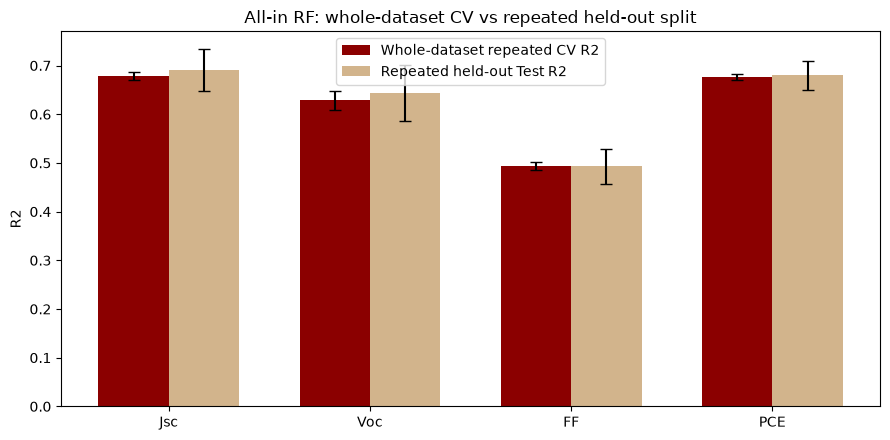

Saved: allin_wholecv_vs_holdout_outputs/bar_wholecv_vs_heldout_r2.png


In [9]:
# ============================================================
# 7a. Bar plot: Whole CV mean vs repeated held-out mean
# ============================================================

plot_df = comparison_summary.copy()
plot_order = ["Jsc", "Voc", "FF", "PCE"]
plot_df["target_short"] = pd.Categorical(plot_df["target_short"], categories=plot_order, ordered=True)
plot_df = plot_df.sort_values("target_short")

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 4.5))
plt.bar(
    x - width/2,
    plot_df["Whole_CV_R2_mean"],
    width,
    yerr=plot_df["Whole_CV_R2_std_across_runs"].fillna(0),
    capsize=4,
    label="Whole-dataset repeated CV R2", color="darkred"
)
plt.bar(
    x + width/2,
    plot_df["Heldout_Test_R2_mean"],
    width,
    yerr=plot_df["Heldout_Test_R2_std"].fillna(0),
    capsize=4,
    label="Repeated held-out Test R2", color="tan"
)
plt.xticks(x, plot_df["target_short"].astype(str))
plt.ylabel("R2")
plt.title("All-in RF: whole-dataset CV vs repeated held-out split")
plt.legend()
plt.tight_layout()
out_path = OUTPUT_DIR / "bar_wholecv_vs_heldout_r2.png"
plt.savefig(out_path, dpi=200)
plt.show()
print("Saved:", out_path)


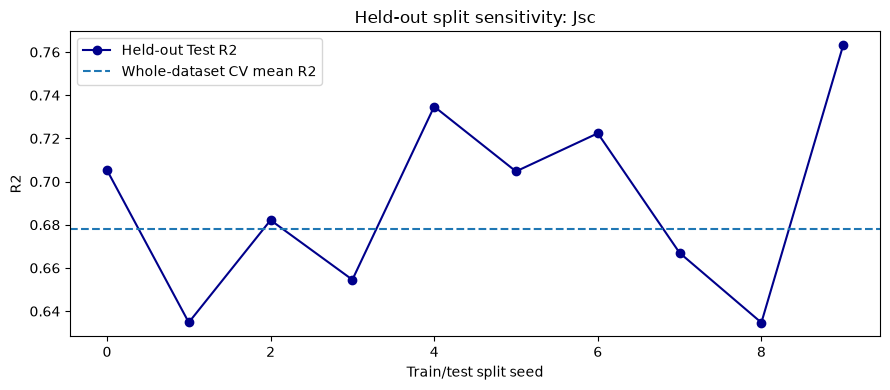

Saved: allin_wholecv_vs_holdout_outputs/line_heldout_r2_vs_wholecv_ref_Jsc.png


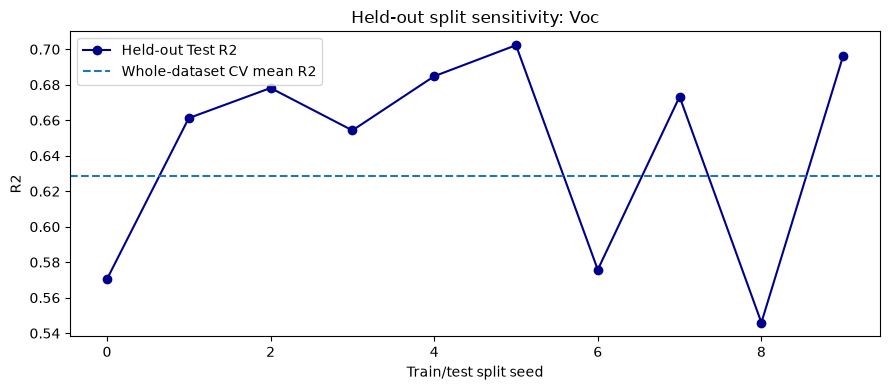

Saved: allin_wholecv_vs_holdout_outputs/line_heldout_r2_vs_wholecv_ref_Voc.png


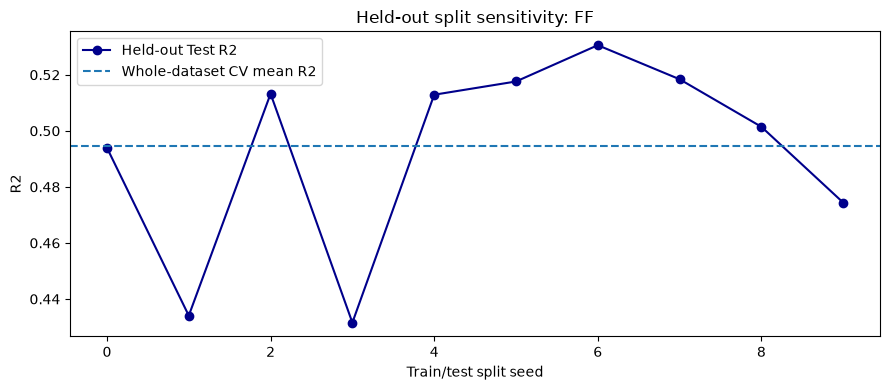

Saved: allin_wholecv_vs_holdout_outputs/line_heldout_r2_vs_wholecv_ref_FF.png


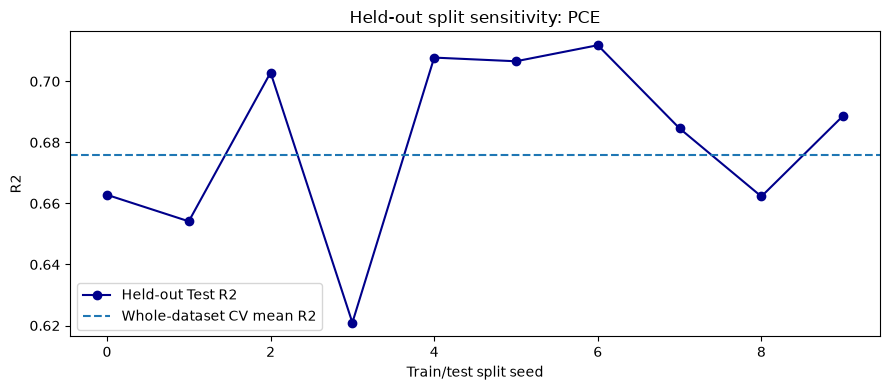

Saved: allin_wholecv_vs_holdout_outputs/line_heldout_r2_vs_wholecv_ref_PCE.png


In [10]:
# ============================================================
# 7b. Line plot: held-out Test R2 across split seeds
# ============================================================

for target_short in plot_order:
    d = holdout_df[holdout_df["target_short"] == target_short].sort_values("split_seed")
    if d.empty:
        continue

    cv_ref = comparison_summary.loc[comparison_summary["target_short"] == target_short, "Whole_CV_R2_mean"]
    cv_ref = cv_ref.iloc[0] if len(cv_ref) else np.nan

    plt.figure(figsize=(9, 4))
    plt.plot(d["split_seed"], d["Test_R2"], marker="o", label="Held-out Test R2", color="darkblue")
    if not np.isnan(cv_ref):
        plt.axhline(cv_ref, linestyle="--", label="Whole-dataset CV mean R2")
    plt.xlabel("Train/test split seed")
    plt.ylabel("R2")
    plt.title(f"Held-out split sensitivity: {target_short}")
    plt.legend()
    plt.tight_layout()
    out_path = OUTPUT_DIR / f"line_heldout_r2_vs_wholecv_ref_{target_short}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)


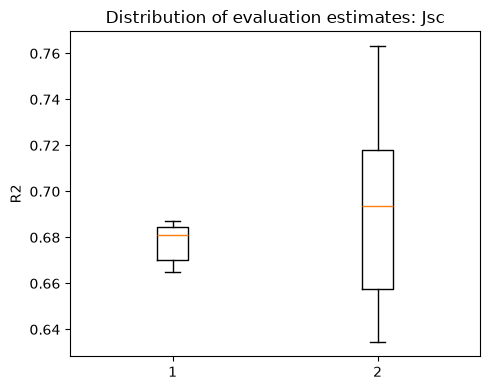

Saved: allin_wholecv_vs_holdout_outputs/box_wholecv_vs_heldout_r2_Jsc.png


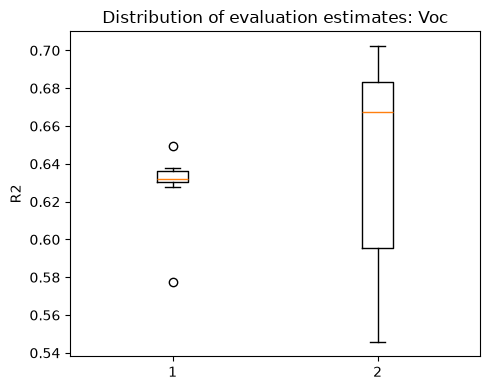

Saved: allin_wholecv_vs_holdout_outputs/box_wholecv_vs_heldout_r2_Voc.png


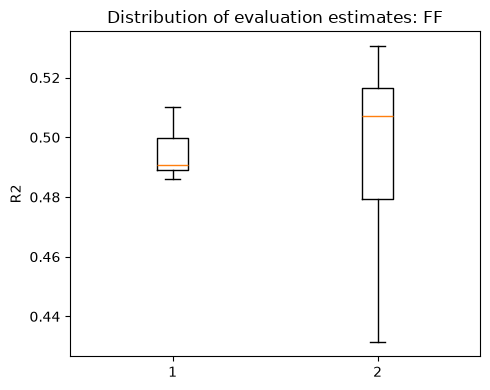

Saved: allin_wholecv_vs_holdout_outputs/box_wholecv_vs_heldout_r2_FF.png


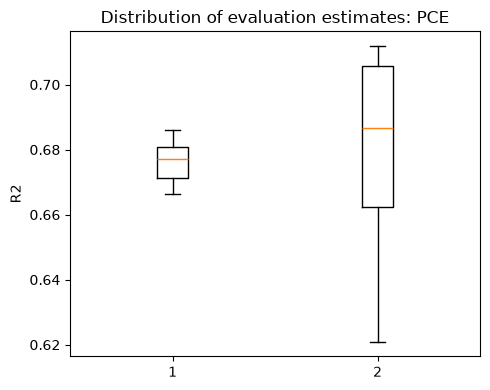

Saved: allin_wholecv_vs_holdout_outputs/box_wholecv_vs_heldout_r2_PCE.png


In [12]:
# ============================================================
# 7c. Boxplot: whole-CV run means vs held-out test scores
# ============================================================

for target_short in plot_order:
    cv_values = whole_cv_df.loc[whole_cv_df["target_short"] == target_short, "CV_R2_mean"].dropna().values
    test_values = holdout_df.loc[holdout_df["target_short"] == target_short, "Test_R2"].dropna().values

    if len(cv_values) == 0 or len(test_values) == 0:
        continue

    plt.figure(figsize=(5, 4))
    plt.boxplot([cv_values, test_values], label=["Whole CV\nrun means", "Held-out\ntest scores"])
    plt.ylabel("R2")
    plt.title(f"Distribution of evaluation estimates: {target_short}")
    plt.tight_layout()
    out_path = OUTPUT_DIR / f"box_wholecv_vs_heldout_r2_{target_short}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)
